030925  Adding LR scheduler 

In [1]:
import torch
import torch.optim.lr_scheduler as lr_scheduler
import wandb
import sys
sys.path.append('../../.')
from modelCardsP3Direction import Cards, get_lin_lay, return_card
from HP_manager import _go


import torch
import torch.nn as nn
from torchvision.models import vgg16, resnet18
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim as optim

from torch.utils.data import DataLoader
#from torch.Utils.data import DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

# general maths and image manipulation
import numpy as np
import cv2

# general other
from datetime import date
from tqdm import tqdm
import pprint
import collections
from IPython.display import clear_output
import time
import random


# saving in file types
import csv
import json
import pickle
import os

# simulation logger
import wandb

# my functions
import sys
sys.path.append('../../.')
from functions import  ImageProcessor
from dataPreProcessingP3Direction import get_data
from dataloaderP3Direction import IDSWDataSetLoader3
from fns4wandb import set_lossfn
#from architectures import eightnnet, PrintLayer
from loopsP3Direction import loop_batch, test_loop_batch, train_val_batch
from plotting import learning_curve, accuracy_curve
from plottingP3Direction import plot_confusion

from modelManagment import choose_model
from modelManagment import choose_scheduler
from fileManagment import save2csv_nest_dict, check_obj4np, save2josn_nested_dict, save2csv, save2json,read_in_json



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/its/home/nn268/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1077, in launch_instance
    app.start()
  File "/its/home/nn268/.local/lib/python3.10

AttributeError: `np.float_` was removed in the NumPy 2.0 release. Use `np.float64` instead.

In [2]:
# directories 

save_location  = "/its/home/nn268/antvis/antvis/optics/res_big_loop_saves/models/p3/NEWLABEL/ComparingBigMods/"

data_path = "/its/home/nn268/antvis/antvis/optics/NC_IDSW/"

gitHASH = "7fb08450bf5961aa0d5c4c1c1860ac569ad8b413"

model_name = 'vgg'#'vgg'#'resnet18'

epochs = 300

tv = [452, 144]

projectNAME = "TEST"#f"LargeModels_ALLLOCS_{model_name}_{tv}_{epochs}E_1e-4_FixedPeakDistERR" #"test"#

In [3]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

modelnames = ["2c2l","3c2l","4c3l","6c3l", "7c3l", "8c3l"]

resolutions = [[452, 144],[226, 72], [113, 36], [57, 18], [29, 9],[15, 5], [8, 3]]

model    res    #
6c3l     452    267520

In [4]:
cards = Cards()
modelcards = cards.modelcards

#"resnet18"#"8c3l"

modelcard = return_card(modelcards, key='name', targetValue=model_name) ########################**************************~~~~~~~~~~~~~~~~###################################
print(f"model card {modelcard}")
resolutioncards = cards.resolutioncards
resolutioncard = return_card(resolutioncards, key='resolution', targetValue=tv)

# : mat1 and mat2 shapes cannot be multiplied (32x267520 and 272384x100)

#modelcard[0]['f_lin_lay'][0] = 267520 

model card [{'name': 'vgg', 'model': 'vgg16', 'f_lin_lay': [200704, 200704, 200704, 200704, 200704, 200704, 200704], 'idx': 0, 'dropout': 0.2}]


print(modelcard)

In [5]:
print(resolutioncards)

[{'resolution': [452, 144], 'padding': 5, 'index': 0}, {'resolution': [226, 72], 'padding': 5, 'index': 1}, {'resolution': [113, 36], 'padding': 2, 'index': 2}, {'resolution': [57, 18], 'padding': 1, 'index': 3}, {'resolution': [29, 9], 'padding': 0, 'index': 4}, {'resolution': [15, 5], 'padding': 0, 'index': 5}, {'resolution': [8, 3], 'padding': 0, 'index': 6}]


In [6]:
# create config dict - add cards and parameters

learning_rate = [1e-4]#[1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

seeds = [56, 22, 42, 7, 56, 23, 22, 69] #[7, 23] #[56, 22, 42, 7, 56, 23, 22, 69]

batchsize = [32]#, 64]


half_ciprange = [22] # 2*half_ciprange + 1  45 = 91, 22 = 45, 11 = 23
std_dev = [7] #2, 3, 4, 5, 6,  constant that scale the gauss curve. if too wide for cliprange there will be a sttep drop
#min_gaussRange = 23
#max_gaussRange = 90


loss_fn = ['MSE']
optim = ["adam"]

scheduler_value = "NoSched"#"RoP"
                      
config = dict({'name': f"Sweep on {model_name} at {resolutioncard[0]['resolution']}_clip:{half_ciprange}"}) #dict({'name' :f"testseep"})#


#min_epoch = 100 # 300
#max_epoch = 200 # 500


# for HP sweep
config.update({"method": "bayes", "metric":{"goal": "minimize", "name": "t_loss"},
              "parameters": {"epochs" :{"value": epochs},
                             "batch_size": {"values": batchsize},
                             "learning_rate":{"values": learning_rate},
                             "loss_fn_cards": {"values":loss_fn},
                             "optimiser": {"values": optim},
                             "seeds": {"values": seeds},
                             "half_ciprange": {"values":half_ciprange},#{"min": min_gaussRange, "max" : max_gaussRange},
                             "std_dev":{"values":std_dev},
                             #'model_cards':{"value":modelcard}, ########################**************************~~~~~~~~~~~~~~~~###################################
                             'model_cards':{"value":model_name}, ########################**************************~~~~~~~~~~~~~~~~###################################
                             'resolution_cards':{"value":resolutioncard}
                            }})


#config.update({"modelcard" : modelcard,
#                "resolutioncard": resolutioncard})
print(config)

{'name': 'Sweep on vgg at [452, 144]_clip:[22]', 'method': 'bayes', 'metric': {'goal': 'minimize', 'name': 't_loss'}, 'parameters': {'epochs': {'value': 3}, 'batch_size': {'values': [32]}, 'learning_rate': {'values': [0.0001]}, 'loss_fn_cards': {'values': ['MSE']}, 'optimiser': {'values': ['adam']}, 'seeds': {'values': [56, 22, 42, 7, 56, 23, 22, 69]}, 'half_ciprange': {'values': [22]}, 'std_dev': {'values': [7]}, 'model_cards': {'value': 'vgg'}, 'resolution_cards': {'value': [{'resolution': [452, 144], 'padding': 5, 'index': 0}]}}}


In [7]:
wandb.login()

wandb: Currently logged in as: naughticalnonsence (antvis). Use `wandb login --relogin` to force relogin


True

In [8]:

def getAcc_fromdict(listdict):
    baseacc = []
    MSE = []
    MAE = []
    peak = []
    for item in listdict:
        baseacc.append(item['baseAcc'])
        MSE.append(item['MSE'])
        MAE.append(item['MAE'])
        peak.append(item['peakDist'])
    return baseacc, MSE, MAE, peak



def _go(config=None):
    d = date.today()
    with wandb.init(config=config):  # config=config, project=f"Big Loop batching of model {mc['name']}", notes=f"big loop batcing {mc['name']}.  {d}.",
        config = wandb.config
        #for seed in seeds:
        #for model_idx, model_card in enumerate(modelcard): #(config['model_cards']):
        if model_name != 'resnet18':
            model_card = modelcard[0]########################**************************~~~~~~~~~~~~~~~~###################################
        start = time.process_time()
        #print("Current allocated memory (GB):", torch.cuda.memory_allocated() / 1024 ** 3)
        #print("MC",model_card) ########################**************************~~~~~~~~~~~~~~~~###################################
        #model_name = model_card['model'] ########################**************************~~~~~~~~~~~~~~~~###################################
        #model_index = model_card['idx']########################**************************~~~~~~~~~~~~~~~~###################################
        #
        
        
        output_lin_lay = 360 ###### Output labels for direction prediction specifically. 
        
        
        #for res_idx, resolution_card in enumerate(resolutioncard):#config['resolution_cards']):
        resolution_card = resolutioncard[0]
        #resolution = resolution_card['resolution']
        resolution = resolution_card['resolution']
        #pad = resolution_card['padding']
        #lin_lay = get_lin_lay(model_card, resolution)
    
        #print('lin lay', lin_lay)

    
        seed = config.seeds # chooses one of the seeds
        #for lossfn_idx, loss in enumerate(config['loss_fn_cards']):
        loss = config.loss_fn_cards
        torch.cuda.empty_cache()

        batch = config.batch_size #['batch_size']

        #print('Model: ', str(model_name), f" idx: {model_idx} / {len(config.model_cards)}")
        #print('resolution: ', str(resolution), f" idx: {res_idx} / {len(config['resolution_cards'])}")
        #print('learning rate: ', str(lr), f" idx: {lr_idx} / {len(config['learning_rate_cards'])}")
        print('seed: ', str(seed))#, f" idx: {seed_idx} / {len(config['seeds'])}")
        print('loss function: ', str(loss))#, f" idx: {lossfn_idx} / {len(config['loss_fn_cards'])}")
        print('Batch size: ', config.batch_size)#['batch_size'])
        print('Training epochs: ', config.epochs)#['epochs'])
        run_start_time = time.process_time()
        print('start time: ',run_start_time)

        #print(time.process_time() - start)

        epochs = config['epochs'] #40

        IP = ImageProcessor(device)

        wandb.log({'gitHash':gitHASH})
        wandb.log({'Epochs': epochs})
        wandb.log({'schedType':scheduler_value})

        
        # set save dictionary
        save_dict = {'Run' : f"{model_name}_{resolution}_{d}",
                     'start_epoch' : 0,
                     'Current_Epoch': 0,
                     'save_location' : save_location,
                    'scheduler': scheduler_value}

        #model = choose_model(model_name, lin_lay, dropout, output_lin_lay).to(device)########################**************************~~~~~~~~~~~~~~~~###################################
        if model_name == 'resnet18':
            model = resnet18(weights=None, num_classes =360).to(device)
        else:
            lin_lay = get_lin_lay(model_card, resolution)
            dropout = model_card['dropout'] 
            print(f"Model Name {model_name}")
            model = choose_model(model_name, lin_lay, dropout, output_lin_lay).to(device)
        #model = smallnet3(in_chan=3, f_lin_lay=int(lin_lay), l_lin_lay=11, ks= (3,5), dropout= dropout).to(device)

        #print('4')
        #!nvidia-smi
        half_ciprange = config.half_ciprange
        std_dev = config.std_dev


        x_train, y_train, x_val, y_val, x_test, y_test = get_data(seed, "/its/home/nn268/antvis/antvis/optics/NC_IDSW/")
        av_lum = IP.new_luminance(x_train)
        train = (x_train, resolution, av_lum, model_name, config.half_ciprange, config.std_dev, batch)
        
        #train_ds = IDSWDataSetLoader3(x_train, resolution,av_lum,model_name, config.gauss_range, config.gauss_width, device)# av_lum, res,pad,
        #train = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, drop_last=True) #, num_workers=2

        #                             x, res, av_lum, model_name, device
        # FOR increases DS size in training via augmentations (yaw augmentations) only create the DSL for test here, Train and Val in epoch loop
        # that will give different yaw augmentations each loop
        # if i also increase epochs, I get more unique tries for direction learning
        
        test_ds= IDSWDataSetLoader3(x_test, resolution,av_lum,model_name, config.half_ciprange, config.std_dev, device)
        test = DataLoader(test_ds, batch_size=config.batch_size, shuffle=True, drop_last=True) #, num_workers=2
       
        #val_ds= IDSWDataSetLoader3(x_val, resolution,av_lum,model_name, config.gauss_range, config.gauss_width, device)
        #val = DataLoader(val_ds, batch_size=config.batch_size, shuffle=True, drop_last=True) #, num_workers=2
        

        print(f"len training : {len(x_train)}     len val : {len(x_val)}    len test : {len(x_test)}")

        loss_fn = set_lossfn(loss)
        
        # set optimizer
        optimizer = torch.optim.Adam(model.parameters(),lr=config.learning_rate)
        scheduler = choose_scheduler(save_dict, optimizer)

        wandb.watch(model, loss_fn, log='all', log_freq=2)#, idx = model_index)

        # moving DL- only inputting x_train, x_val here
        model, save_dict = train_val_batch(model, train, x_val,save_dict, config.learning_rate, loss_fn,epochs, config.batch_size, optimizer, scheduler, device, config)
        
        loop_run_name = f"{save_dict['Run']}_{resolution}_{config.learning_rate}_{scheduler_value}_{seed}_{loss}"
        _save_location = save_dict['save_location']
        test_acc, test_predict_list, y_test = test_loop_batch(model,test, loss_fn, config.batch_size, device, config, runname=loop_run_name, save_loc = _save_location) 
        
        test_predict_numerical = [p.item() for p in test_predict_list]
        y_test_numerical = [y.item() for y in y_test]
        
        print(np.unique(test_predict_list))
        #print(np.unique(y_test))

        
        print(' \n train Acc: ', save_dict['t_accuracy_list'][-1])
        print(' \n val Acc: ', save_dict['v_accuracy_list'][-1])
        print(' \n test Acc: ', test_acc)
        
        save_dict.update({'test_acc': test_acc})
        save_dict.update({'test_predict': test_predict_list})
        save_dict.update({'test_labels': list(y_test)})
        #save_dict.update({'test_loss':test_loss})

        
        t_acc = save_dict['t_accuracy_list']
        tbase_acc, tMSE, tMAE, t_peakdist = getAcc_fromdict(t_acc)
        
        v_acc = save_dict['v_accuracy_list']
        vbase_acc, vMSE, vMAE, v_peakdist = getAcc_fromdict(v_acc)

        
        learning_curve(save_dict['t_loss_list'], save_dict['v_loss_list'], save_location=save_dict['save_location'],run_name=loop_run_name)
        
        accuracy_curve(tbase_acc, vbase_acc ,save_location=save_dict['save_location'],run_name="Basic"+loop_run_name)
        accuracy_curve(tMSE, vMSE ,save_location=save_dict['save_location'],run_name="MSE"+loop_run_name)
        accuracy_curve(tMAE, vMAE ,save_location=save_dict['save_location'],run_name="MAE"+loop_run_name)
        accuracy_curve(t_peakdist, v_peakdist ,save_location=save_dict['save_location'],run_name="PeakDist"+loop_run_name)
        
        #test_predict_list=[pred.cpu() for pred in test_predict_list]   ## pred is not currently a tensor. So not needed.
                                                             ## If pred becomes a tensor - put it back in.

        print(f"test_predict_numerical :   {test_predict_numerical}")
        print(f"y_test_numerical :     {y_test_numerical}")
        plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
        
        
        wandb.log({'test_predict': test_predict_list})
        wandb.log({'test_labels': list(y_test)})
        #saving
        diction = {}
        d = date.today()
        d=str(d)
        diction.update({'Date':d})
        diction.update({'gitHASH':str(gitHASH)})
        diction.update({'model_name': str(model_name)})
        diction.update({'loss_fn': str(loss)})
        diction.update({'lr': str(config.learning_rate)})
        #diction.update({'wd': str(wd_card)})
        #diction.update({'scheduler': str(scheduler_value)})
        diction.update({'seed': str(seed)})
        diction.update({'resolution': str(resolution)})
        #diction.update({'pad': int(pad)})
        #diction.update({'lin_lay': int(lin_lay)})
        diction.update({'run time': (time.process_time() - run_start_time)})
        diction.update(save_dict)
        
        
        title = save_dict['Run']
        save2json(diction, loop_run_name, _save_location)
        save2csv(diction, title, _save_location)

        diction['model.state_dict'] = model.state_dict() #to('cpu').

        with open(f"{save_location}{loop_run_name}_{epochs}.pkl", 'wb+') as f:
            pickle.dump(diction, f)
        
        #clear_output()
        
        print(f' \n END {model_name} {resolution} Run Time: ',time.process_time() - run_start_time)
        #!nvidia-smi
        torch.cuda.empty_cache()

Git Hash registered
Create sweep with ID: qhgxzwkd
Sweep URL: https://wandb.ai/antvis/test/sweeps/qhgxzwkd


wandb: Agent Starting Run: 068tj856 with config:
wandb: 	batch_size: 32
wandb: 	epochs: 3
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: MSE
wandb: 	model_cards: vgg
wandb: 	optimiser: adam
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 23
wandb: 	std_dev: 7


seed:  23
loss function:  MSE
Batch size:  32
Training epochs:  3
start time:  12.881110286
Model Name vgg
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  MSE


  0%|                                 | 0/3 [00:00<?, ?it/s]

Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  90.33184523809524
tacc:  {'baseAcc': 12.5, 'MSE': 0.03256935058605103, 'MAE': 0.07296326756477356, 'peakDist': 90.33184523809524}
Validating...


...

 67%|████████████████▋        | 2/3 [00:14<00:07,  7.37s/it]

peak dist means  95.32465277777777
v loss  0.5862230621278286
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  91.19047619047619
tacc:  {'baseAcc': 9.375, 'MSE': 0.032568285862604775, 'MAE': 0.07296271356088775, 'peakDist': 91.19047619047619}
Validating...


100%|█████████████████████████| 3/3 [00:22<00:00,  7.34s/it]

peak dist means  87.66840277777777
v loss  0.5862232111394405


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


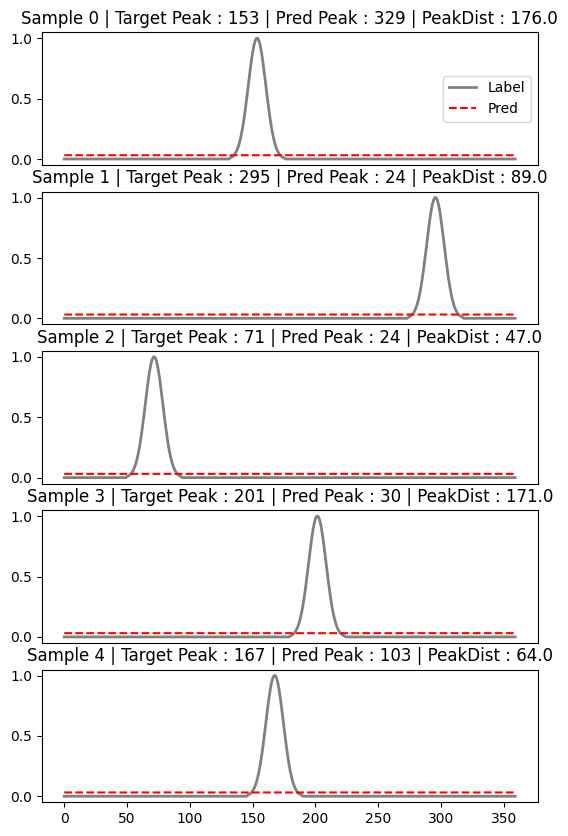

[  4  11  12  19  21  23  24  25  28  29  30  32  33  34  39  45  46  48
  49  60  61  63  64  66  68  71  72  78  80  82  85  88  91  94  96  99
 101 103 105 109 116 117 127 136 142 143 144 148 153 159 160 162 168 173
 174 184 190 193 195 197 204 207 216 218 220 226 229 234 236 237 239 240
 244 246 247 253 254 255 256 257 268 270 271 275 276 277 278 281 283 284
 285 286 289 291 293 294 298 302 303 311 313 314 315 320 327 329 330 331
 332 335 336 338 341 343 345 346 347 349 351 356 359]
 
 train Acc:  {'baseAcc': 9.375, 'MSE': 0.032568285862604775, 'MAE': 0.07296271356088775, 'peakDist': 91.19047619047619}
 
 val Acc:  {'baseAcc': 9.375, 'MSE': 0.03256795493264993, 'MAE': 0.07296191031734149, 'peakDist': 87.66840277777777}
 
 test Acc:  {'BaseAcc': [6.25, 6.25, 12.5, 6.25, 21.875, 18.75, 12.5, 12.5, 6.25, 0.0, 12.5, 6.25, 18.75, 3.125, 9.375, 12.5, 6.25, 3.125, 6.25, 9.375, 3.125, 9.375, 18.75, 12.5, 15.625], 'MSE': [0.032567963004112244, 0.03256790339946747, 0.03256794437766075, 0.032

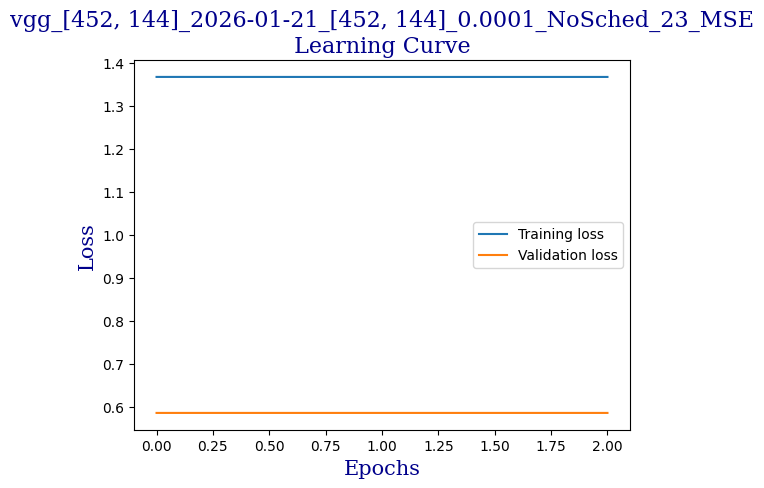

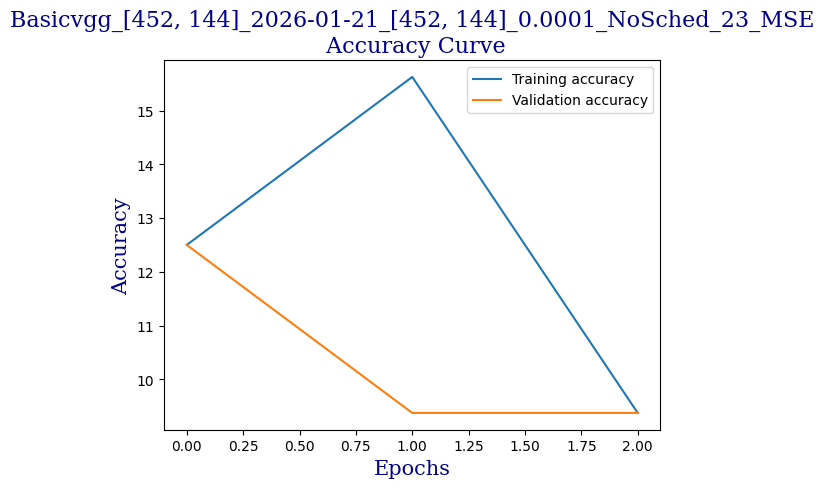

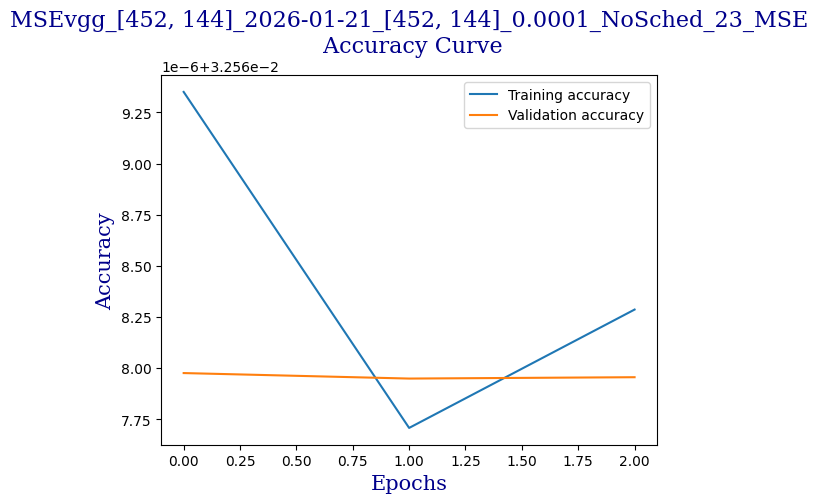

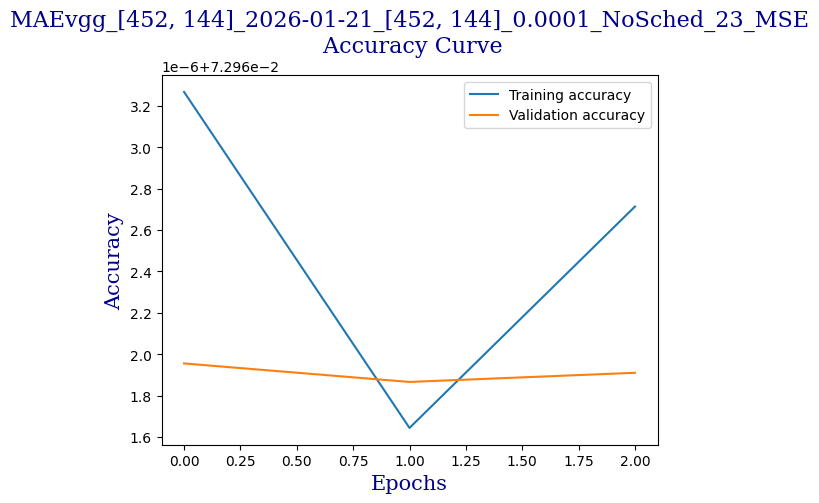

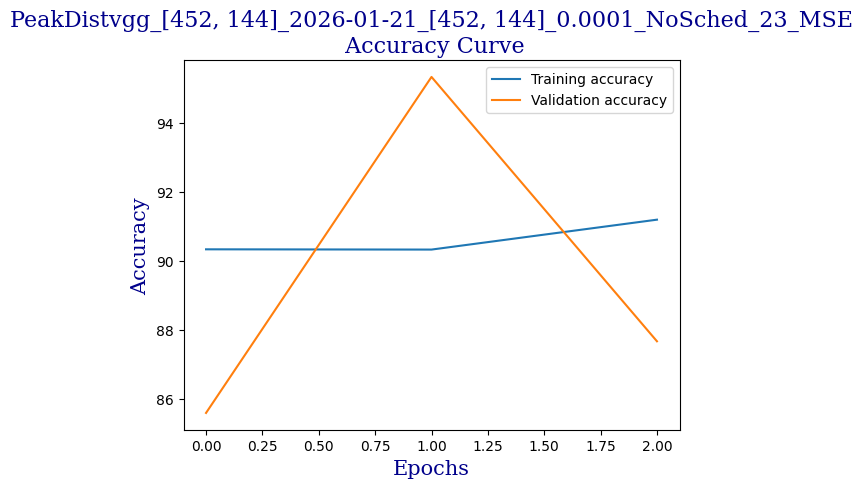

test_predict_numerical :   [24, 60, 329, 24, 85, 162, 162, 346, 153, 313, 329, 277, 320, 136, 162, 162, 341, 311, 60, 313, 60, 286, 105, 105, 244, 60, 60, 359, 162, 320, 21, 302, 162, 105, 60, 162, 341, 29, 24, 60, 195, 60, 162, 60, 162, 60, 162, 24, 30, 34, 239, 286, 327, 286, 286, 60, 237, 25, 64, 237, 289, 162, 162, 311, 60, 253, 60, 162, 286, 34, 34, 276, 60, 136, 162, 336, 237, 60, 143, 39, 24, 162, 60, 162, 99, 127, 220, 60, 82, 255, 162, 341, 80, 162, 12, 60, 68, 286, 162, 236, 34, 162, 60, 148, 60, 60, 60, 117, 25, 286, 60, 162, 39, 88, 64, 329, 12, 162, 60, 320, 162, 80, 60, 162, 193, 24, 105, 286, 345, 336, 162, 162, 162, 162, 19, 60, 32, 60, 162, 60, 173, 105, 64, 336, 60, 24, 105, 244, 12, 162, 302, 162, 237, 311, 184, 60, 30, 85, 162, 25, 60, 61, 286, 286, 85, 162, 60, 253, 253, 275, 60, 162, 162, 286, 162, 60, 253, 162, 159, 60, 25, 253, 60, 341, 315, 103, 311, 286, 24, 30, 60, 60, 343, 253, 162, 162, 85, 60, 311, 105, 60, 60, 24, 105, 289, 286, 293, 345, 286, 60, 286, 60

Traceback (most recent call last):
  File "/tmp/ipykernel_168506/3714808312.py", line 167, in _go
    plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
  File "/its/home/nn268/antvis/antvis/optics/Batchcode/p3/../.././plottingP3Direction.py", line 70, in plot_confusion
    disp.plot(cmap='plasma')
  File "/its/home/nn268/.local/lib/python3.10/site-packages/sklearn/metrics/_plot/confusion_matrix.py", line 181, in plot
    ax.set(
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 146, in <lambda>
    cls.set = lambda self, **kwargs: Artist.set(self, **kwargs)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1241, in set
    return self._internal_update(cbook.normalize_kwargs(kwargs, self))
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1233, in 

Epochs,▁
Test acc rough,▃▃▅▃█▇▅▅▃▁▅▃▇▂▄▅▃▂▃▄▂▄▇▅▆
TrainAcc rough,▃▃▃▅▅▅▇▅▄▅▃▃▅▅▃▅▆▄▃▂█▅▅▅▅▃▅▃▅▃▆▆▆▅▅▄▁▃▇▄
ValAcc rough,▄▆▅▄▄▇▅▅█▅▁▄▄▅▅█▅▄▇▅▅▄▅▄▂▂▄▄▄▃▃▄▄▆█▆█▄▆▄
c_epoch,▁▅█
t_loss,█▁▃
test_acc_MAE,▇▃▆▆▇▅▅▇▆▇▄▆▁▆▅▄▇▅▆▅▅▄▇█▄
test_acc_MSE,▅▃▅▅█▃▄▆▇▆▄▆▁▆▆▃▆▅▅▅▅▃▆█▃
test_peakDist,▅▇▆█▃▄▇▁▅▆▇▅▃▆▃▆▇▇▄▄▅▅▃▅▆
train_err_MAE,▃█▆▁▆▅▄▄▃▃▃▄▃▄▃▃▂▄▃▄▂▄▄▃▂▃▃▅▄▄▄▃▃▄▄▃▃▃▃▃
train_err_MSE,▁█▄▂▆▅▄▃▃▃▃▃▃▃▃▃▁▂▃▃▂▃▄▂▃▂▂▄▃▃▃▂▃▃▃▃▃▂▂▂


Run 068tj856 errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: ERROR Run 068tj856 errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: Agent Starting Run: 0qz0j24x with config:
wandb: 	batch_size: 32
wandb: 	epochs: 3
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: MSE
wandb: 	model_cards: vgg
wandb: 	optimiser: adam
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 56
wandb: 	std_dev: 7


seed:  56
loss function:  MSE
Batch size:  32
Training epochs:  3
start time:  239.847728535
Model Name vgg
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  MSE


...

 67%|████████████████▋        | 2/3 [00:14<00:07,  7.21s/it]

peak dist means  95.23611111111111
v loss  0.5862233750522137
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  89.24702380952381
tacc:  {'baseAcc': 9.375, 'MSE': 0.032568191488583885, 'MAE': 0.07296218864974521, 'peakDist': 89.24702380952381}
Validating...


100%|█████████████████████████| 3/3 [00:21<00:00,  7.20s/it]

peak dist means  94.140625
v loss  0.586223341524601


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


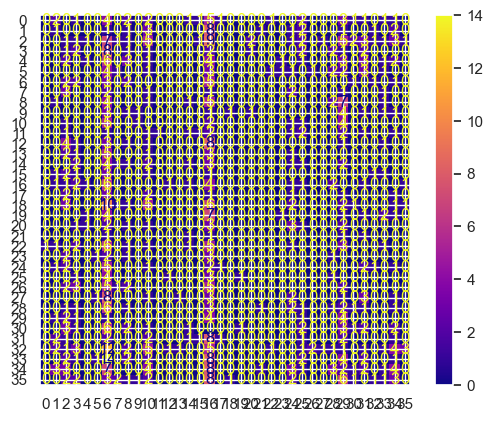

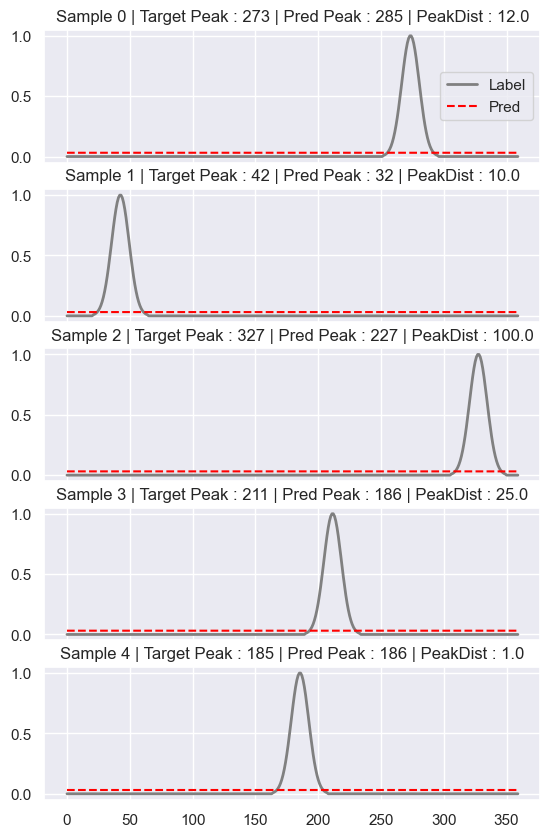

[  1   7   9  10  11  12  14  20  22  28  32  37  39  41  42  43  46  48
  49  52  59  64  65  66  69  70  72  73  74  76  77  78  84  85  86  88
  89  92  93  96 101 114 115 116 118 121 122 124 125 127 129 130 131 132
 133 134 137 138 140 143 144 145 146 150 153 157 158 161 165 168 172 174
 184 186 187 188 189 190 194 203 204 209 210 212 214 216 217 224 227 228
 229 231 233 235 236 237 245 250 251 252 253 254 258 262 264 266 267 274
 281 283 285 292 295 299 304 306 307 310 311 315 316 317 321 324 325 327
 338 345 347 350 351 352 353 356]
 
 train Acc:  {'baseAcc': 9.375, 'MSE': 0.032568191488583885, 'MAE': 0.07296218864974521, 'peakDist': 89.24702380952381}
 
 val Acc:  {'baseAcc': 18.75, 'MSE': 0.03256796196930938, 'MAE': 0.07296192025144894, 'peakDist': 94.140625}
 
 test Acc:  {'BaseAcc': [6.25, 3.125, 9.375, 15.625, 12.5, 3.125, 6.25, 6.25, 15.625, 21.875, 9.375, 15.625, 15.625, 15.625, 9.375, 18.75, 9.375, 9.375, 15.625, 18.75, 12.5, 6.25, 12.5, 9.375, 18.75], 'MSE': [0.032567981

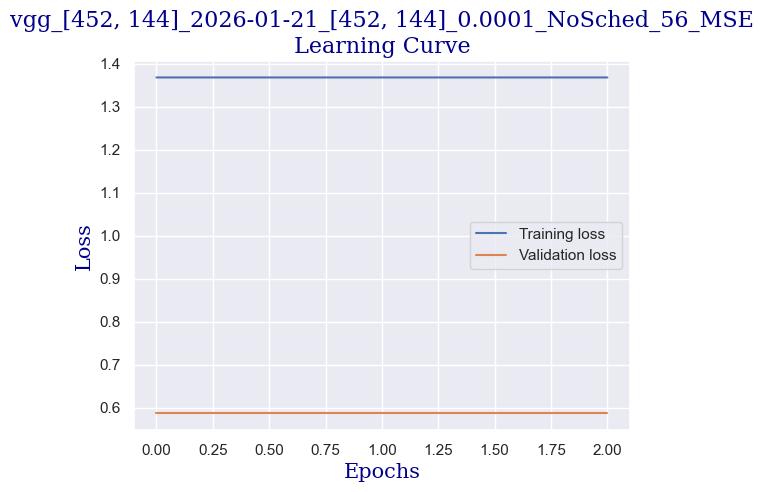

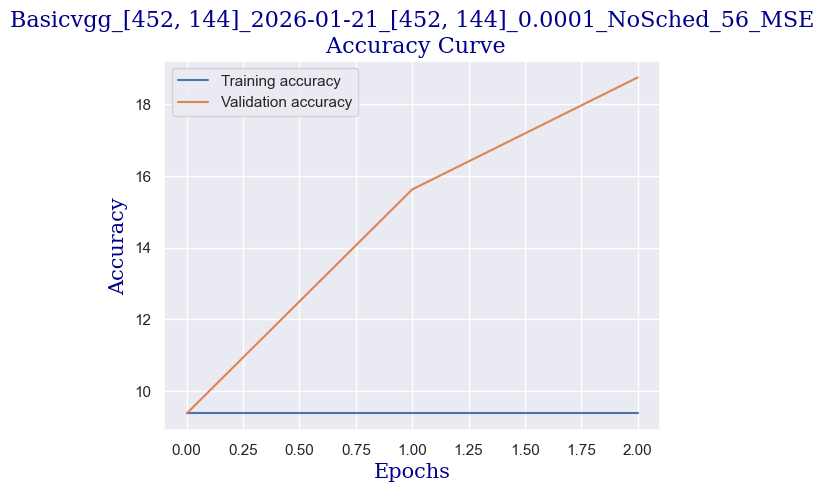

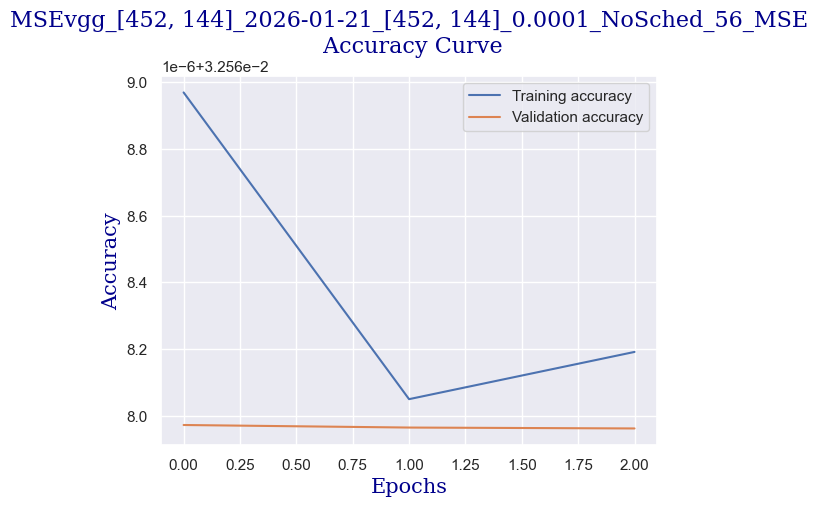

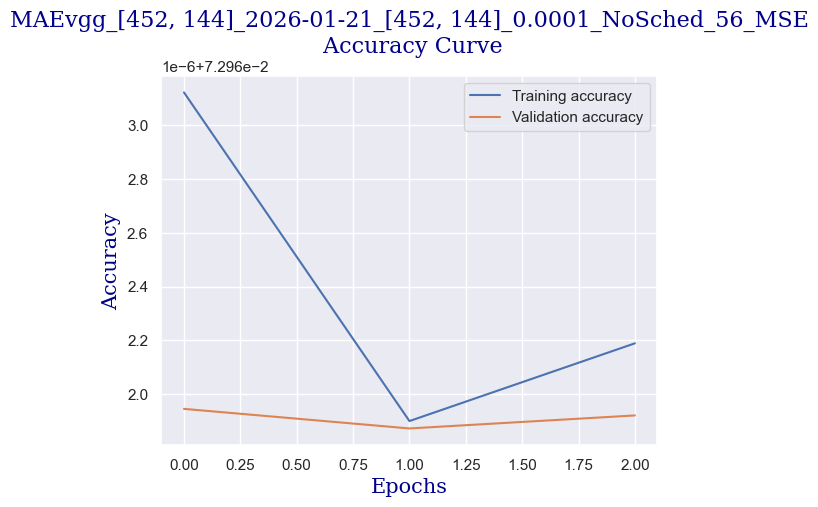

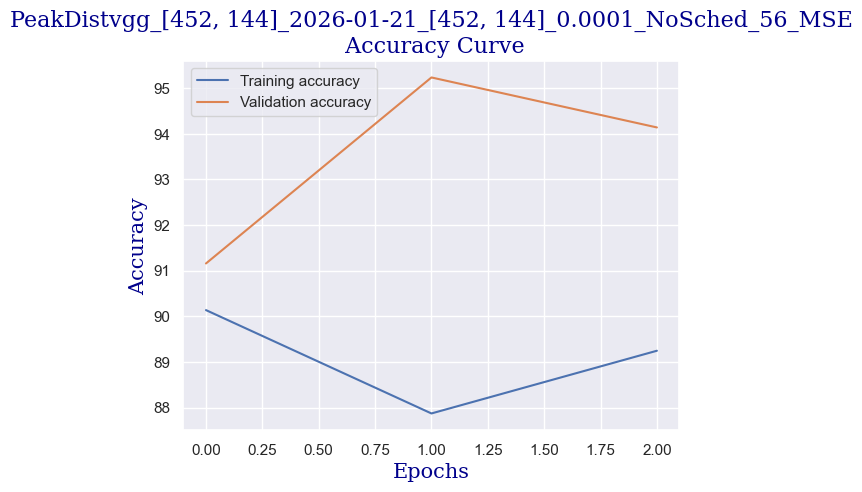

test_predict_numerical :   [227, 227, 158, 227, 124, 209, 88, 138, 124, 172, 306, 227, 231, 131, 306, 227, 114, 186, 186, 186, 227, 306, 306, 227, 227, 153, 153, 153, 350, 153, 227, 130, 146, 227, 306, 186, 227, 227, 127, 187, 134, 138, 186, 187, 227, 306, 227, 227, 299, 227, 227, 84, 172, 307, 186, 186, 186, 227, 227, 186, 165, 227, 227, 227, 227, 306, 186, 250, 172, 143, 227, 227, 227, 186, 217, 350, 186, 186, 131, 186, 137, 227, 227, 134, 227, 227, 245, 127, 20, 350, 227, 227, 231, 229, 131, 186, 186, 186, 227, 186, 227, 306, 227, 227, 227, 217, 245, 186, 311, 227, 227, 210, 227, 227, 306, 304, 227, 116, 186, 186, 258, 52, 306, 217, 172, 227, 227, 227, 283, 204, 227, 186, 351, 172, 217, 153, 172, 229, 306, 227, 227, 129, 186, 227, 262, 227, 186, 350, 43, 214, 153, 227, 235, 190, 283, 127, 186, 84, 124, 227, 306, 227, 77, 227, 131, 227, 227, 227, 186, 129, 1, 227, 138, 186, 194, 217, 227, 258, 187, 84, 227, 186, 186, 186, 237, 258, 253, 133, 227, 1, 186, 227, 227, 73, 306, 131, 46, 2

Traceback (most recent call last):
  File "/tmp/ipykernel_168506/3714808312.py", line 167, in _go
    plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
  File "/its/home/nn268/antvis/antvis/optics/Batchcode/p3/../.././plottingP3Direction.py", line 70, in plot_confusion
    disp.plot(cmap='plasma')
  File "/its/home/nn268/.local/lib/python3.10/site-packages/sklearn/metrics/_plot/confusion_matrix.py", line 181, in plot
    ax.set(
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 146, in <lambda>
    cls.set = lambda self, **kwargs: Artist.set(self, **kwargs)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1241, in set
    return self._internal_update(cbook.normalize_kwargs(kwargs, self))
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1233, in 

Epochs,▁
Test acc rough,▂▁▃▆▅▁▂▂▆█▃▆▆▆▃▇▃▃▆▇▅▂▅▃▇
TrainAcc rough,▂▂▄▅▃▄▂▅▁▁▄▂▆▃▂█▄▅▅▂▇▃▇▃▃▅▃▃█▅▁▆▅▄▃▂▃▂▅▃
ValAcc rough,▄▄▄▅▁▅▅▅▃▄▄▅▅▄▇█▂▄▃▅▅▃▇▃▅▅▅▄▂▅▇▄▃▆▄▆▄▄▅▆
c_epoch,▁▅█
t_loss,█▁▂
test_acc_MAE,▅█▇▁▅▅▄▆▆▆█▅▄▆▆▅█▇▅▃▅▅▂▄▅
test_acc_MSE,▇██▂▄▆▄▇▇▆█▅▂▃▅▆█▆▅▃▆▂▁▅▅
test_peakDist,▆▅▃▄▄█▇▅▂▁▄▃▄█▂▃▆▆▇▆▅▇▅▃▃
train_err_MAE,▄▄▁▇█▄▆▅▄▄▅▄▄▄▅▄▄▅▄▅▄▅▄▄▄▅▅▅▄▄▆▄▅▄▄▄▅▄▄▅
train_err_MSE,▅▄▁██▄▅▅▄▄▅▅▄▄▅▅▅▄▅▅▄▅▅▄▄▅▅▅▄▄▅▅▅▄▅▅▅▄▅▅


Run 0qz0j24x errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: ERROR Run 0qz0j24x errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: Agent Starting Run: w2vl51a7 with config:
wandb: 	batch_size: 32
wandb: 	epochs: 3
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: MSE
wandb: 	model_cards: vgg
wandb: 	optimiser: adam
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 56
wandb: 	std_dev: 7


seed:  56
loss function:  MSE
Batch size:  32
Training epochs:  3
start time:  462.28122789
Model Name vgg
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  MSE


...

 67%|████████████████▋        | 2/3 [00:14<00:07,  7.10s/it]

peak dist means  88.52083333333333
v loss  0.5862230062484741
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  91.45238095238095
tacc:  {'baseAcc': 15.625, 'MSE': 0.03256817836137045, 'MAE': 0.07296235096596536, 'peakDist': 91.45238095238095}
Validating...


100%|█████████████████████████| 3/3 [00:21<00:00,  7.10s/it]

peak dist means  94.54513888888889
v loss  0.5862235091626644


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


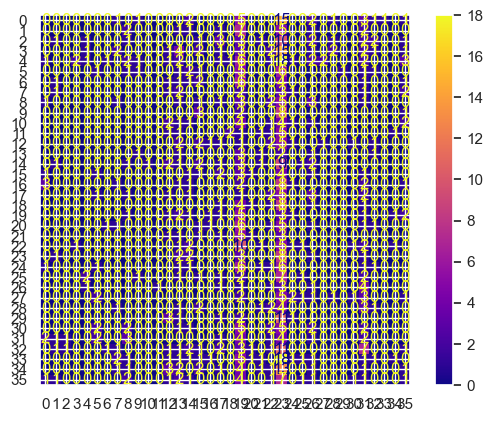

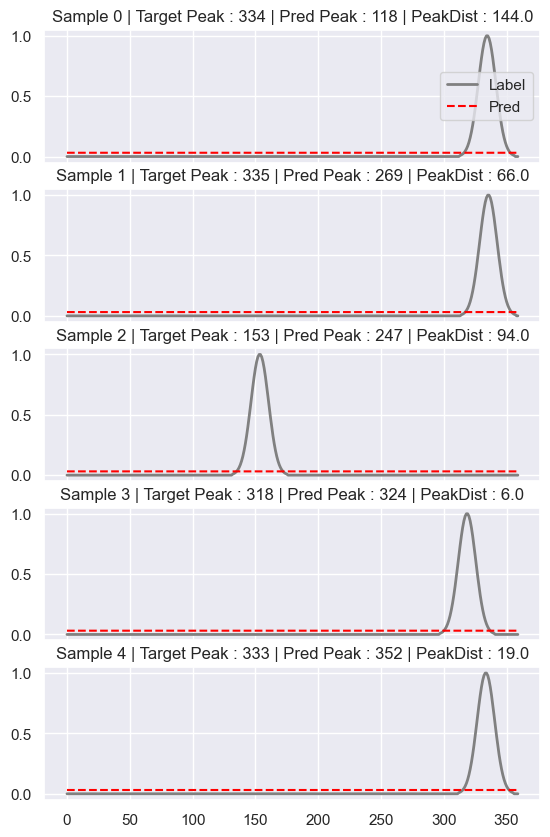

[  0   4  10  12  15  17  19  23  24  25  27  30  33  34  36  37  42  44
  45  46  49  50  52  53  55  56  57  58  59  62  63  70  71  73  75  77
  83  86  87  91  92  94  97 100 104 107 108 109 110 114 115 116 117 118
 125 130 131 137 139 140 144 145 151 152 153 154 155 157 158 159 163 164
 173 176 177 179 181 187 188 189 191 195 197 200 202 203 205 206 210 211
 213 214 216 219 220 221 222 224 232 233 234 240 241 243 244 246 247 249
 250 251 252 255 264 266 267 269 270 272 276 277 280 284 285 286 287 289
 290 291 292 293 297 299 302 305 307 308 310 314 317 318 319 321 324 327
 330 334 337 338 340 342 345 346 347 348 349 350 351 352 357 358]
 
 train Acc:  {'baseAcc': 15.625, 'MSE': 0.03256817836137045, 'MAE': 0.07296235096596536, 'peakDist': 91.45238095238095}
 
 val Acc:  {'baseAcc': 9.375, 'MSE': 0.032567972110377416, 'MAE': 0.07296194136142731, 'peakDist': 94.54513888888889}
 
 test Acc:  {'BaseAcc': [6.25, 9.375, 15.625, 15.625, 21.875, 0.0, 15.625, 21.875, 21.875, 12.5, 3.125, 9.

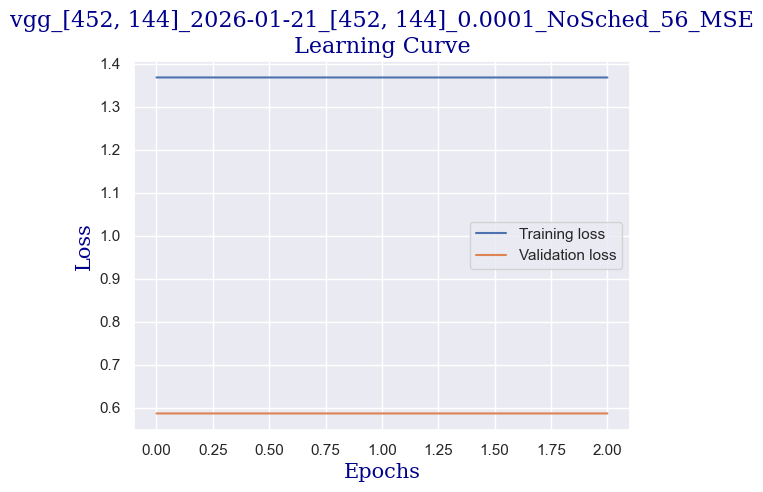

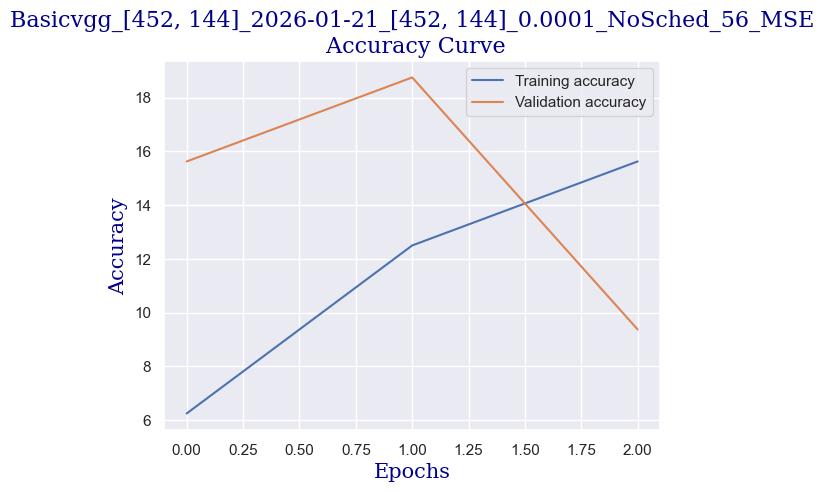

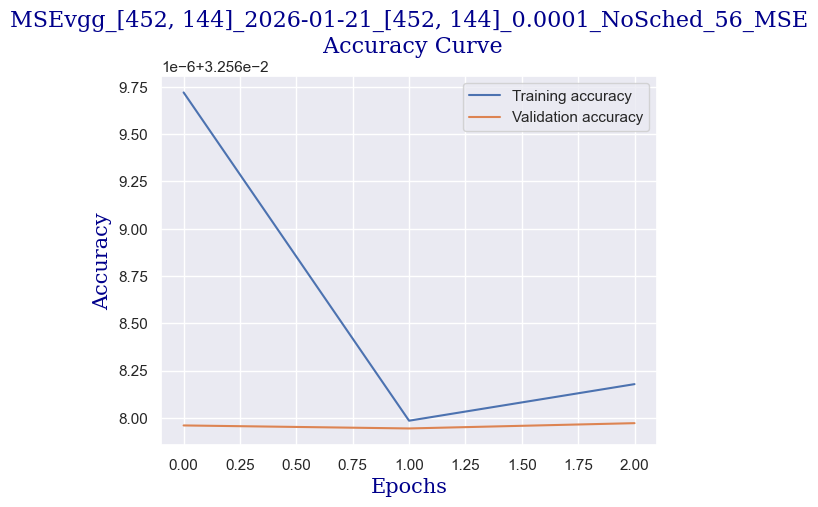

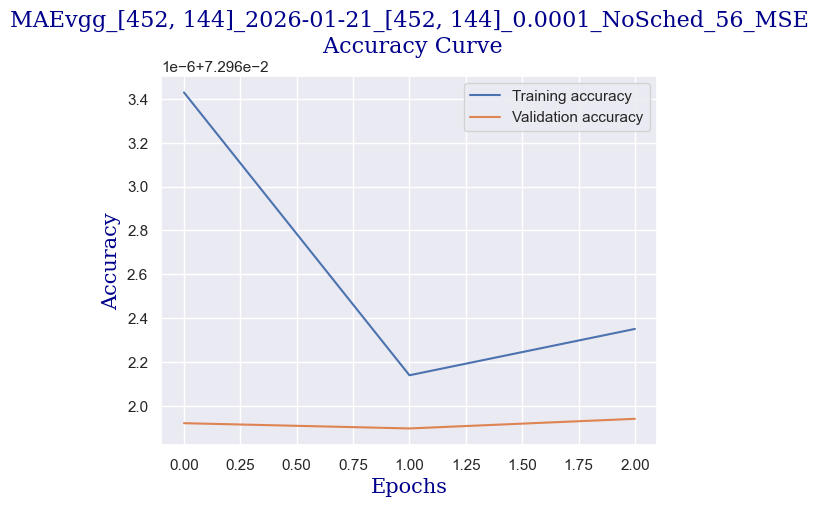

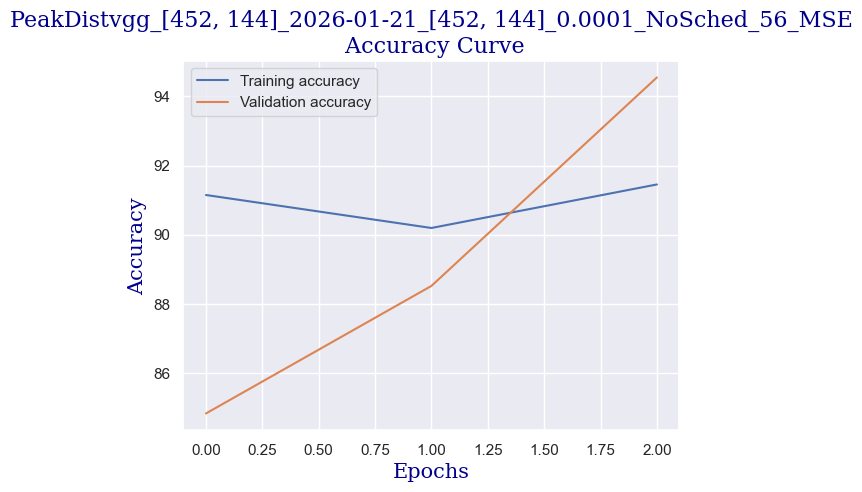

test_predict_numerical :   [137, 118, 25, 247, 299, 299, 299, 289, 244, 224, 53, 110, 57, 299, 285, 243, 10, 110, 62, 224, 244, 232, 342, 267, 151, 144, 197, 286, 352, 276, 202, 211, 352, 118, 110, 125, 75, 197, 30, 352, 352, 297, 57, 299, 23, 118, 57, 289, 137, 299, 342, 117, 241, 224, 118, 299, 158, 276, 34, 83, 297, 342, 297, 299, 342, 176, 110, 191, 110, 289, 247, 181, 299, 97, 299, 299, 154, 206, 352, 352, 23, 118, 330, 289, 299, 352, 118, 176, 284, 299, 118, 109, 276, 144, 299, 342, 25, 232, 232, 299, 176, 86, 63, 289, 118, 243, 357, 299, 4, 305, 297, 244, 232, 299, 352, 118, 115, 23, 299, 144, 118, 23, 176, 299, 299, 25, 214, 234, 118, 270, 299, 247, 176, 276, 348, 222, 176, 299, 23, 176, 299, 216, 299, 342, 144, 33, 56, 57, 4, 299, 334, 350, 118, 77, 15, 243, 224, 118, 139, 255, 206, 118, 297, 299, 195, 118, 240, 177, 352, 137, 110, 249, 299, 110, 56, 50, 289, 232, 23, 110, 144, 139, 58, 250, 110, 118, 299, 247, 299, 176, 118, 352, 297, 299, 118, 25, 139, 289, 57, 118, 213, 352

Traceback (most recent call last):
  File "/tmp/ipykernel_168506/3714808312.py", line 167, in _go
    plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
  File "/its/home/nn268/antvis/antvis/optics/Batchcode/p3/../.././plottingP3Direction.py", line 70, in plot_confusion
    disp.plot(cmap='plasma')
  File "/its/home/nn268/.local/lib/python3.10/site-packages/sklearn/metrics/_plot/confusion_matrix.py", line 181, in plot
    ax.set(
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 146, in <lambda>
    cls.set = lambda self, **kwargs: Artist.set(self, **kwargs)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1241, in set
    return self._internal_update(cbook.normalize_kwargs(kwargs, self))
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1233, in 

Epochs,▁
Test acc rough,▃▄▆▆█▁▆██▅▂▄▅▆▅▆▄▆██▃▇▂▃▇
TrainAcc rough,▂▃▁▆▃▄▅▄▂▄▆▂▄▂▃▅▅▅▅▅▆▄▄▅▂▅▄█▅▃▂▂▃▁▂▂▂▅▅▅
ValAcc rough,▆▄▅▃▅█▅▅▆▆▃▆█▅▄▅▅▄█▅▃▄▄▄▆▆▆▃▅▃▄▇▅▁▅▄▃▅▃▄
c_epoch,▁▅█
t_loss,█▁▂
test_acc_MAE,▄▅▃▇▄▃▆▆▂▄▆▃▃▄▁▄▃▁▂▄▆▂█▇▃
test_acc_MSE,▅▄▃█▄▂▅▆▃▃▆▂▃▄▁▂▄▁▃▅▅▃█▅▃
test_peakDist,█▅▂▄▆█▅▁▃▇█▄▇▇▅▃▄▆▂▁▅▄▅▇▆
train_err_MAE,▃█▂▁▅▃▃▂▃▄▃▃▃▃▄▃▃▄▃▃▃▃▃▃▃▃▃▃▃▃▄▃▃▃▄▄▃▃▃▃
train_err_MSE,▃█▂▁▃▃▂▂▂▃▂▂▂▃▃▂▂▃▂▂▂▂▂▂▂▂▃▂▂▂▂▃▂▂▃▃▂▂▂▂


Run w2vl51a7 errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: ERROR Run w2vl51a7 errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: Agent Starting Run: pzmxwytt with config:
wandb: 	batch_size: 32
wandb: 	epochs: 3
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: MSE
wandb: 	model_cards: vgg
wandb: 	optimiser: adam
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 23
wandb: 	std_dev: 7


seed:  23
loss function:  MSE
Batch size:  32
Training epochs:  3
start time:  679.135936649
Model Name vgg
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  MSE


...

 67%|████████████████▋        | 2/3 [00:14<00:07,  7.16s/it]

peak dist means  85.58159722222223
v loss  0.5862235315144062
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  88.93973214285714
tacc:  {'baseAcc': 3.125, 'MSE': 0.03256801657733463, 'MAE': 0.07296191776792209, 'peakDist': 88.93973214285714}
Validating...


100%|█████████████████████████| 3/3 [00:21<00:00,  7.13s/it]

peak dist means  88.65972222222223
v loss  0.586223166435957


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


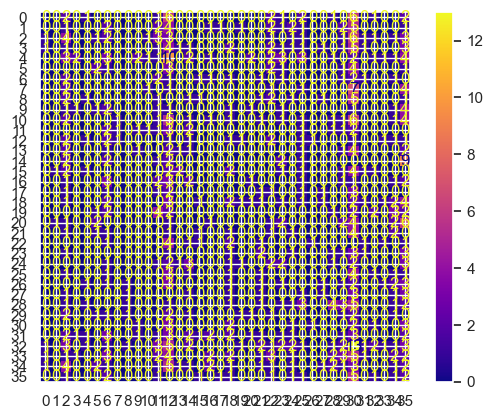

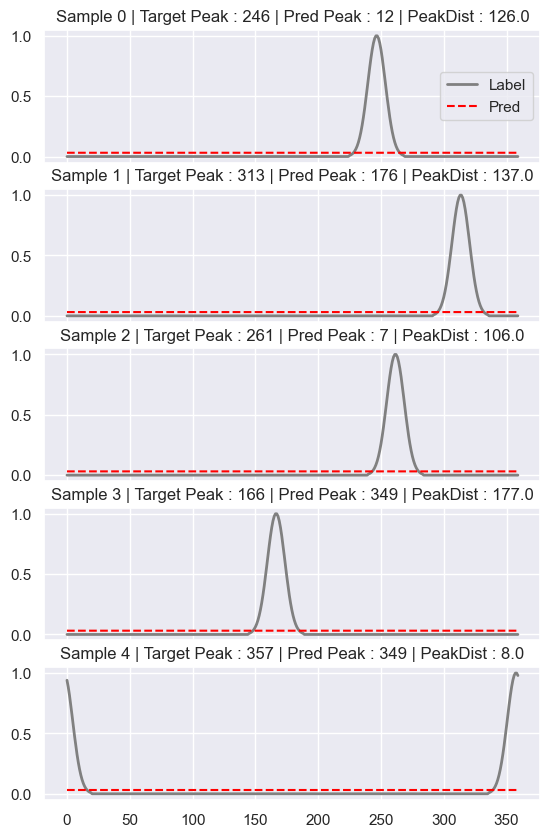

[  0   3   5   7   9  12  19  22  23  26  30  32  33  35  40  45  46  47
  50  51  58  66  67  71  81  86  88  89  93  94  95  96  97 102 109 112
 115 117 118 120 122 124 131 133 135 138 139 140 143 152 156 159 160 164
 166 170 173 175 176 181 191 194 196 197 198 200 203 204 205 210 211 213
 220 222 228 232 233 238 241 251 252 257 259 261 262 265 267 269 272 273
 276 277 281 283 287 290 291 294 295 297 299 303 306 313 315 318 322 326
 329 330 332 333 334 337 338 340 342 343 349 350 351 353 355 357]
 
 train Acc:  {'baseAcc': 3.125, 'MSE': 0.03256801657733463, 'MAE': 0.07296191776792209, 'peakDist': 88.93973214285714}
 
 val Acc:  {'baseAcc': 15.625, 'MSE': 0.032567953483925924, 'MAE': 0.07296191362871064, 'peakDist': 88.65972222222223}
 
 test Acc:  {'BaseAcc': [12.5, 18.75, 15.625, 15.625, 15.625, 9.375, 25.0, 12.5, 18.75, 9.375, 18.75, 28.125, 6.25, 21.875, 9.375, 21.875, 18.75, 9.375, 12.5, 3.125, 21.875, 6.25, 9.375, 12.5, 15.625], 'MSE': [0.03256794810295105, 0.03256801515817642, 

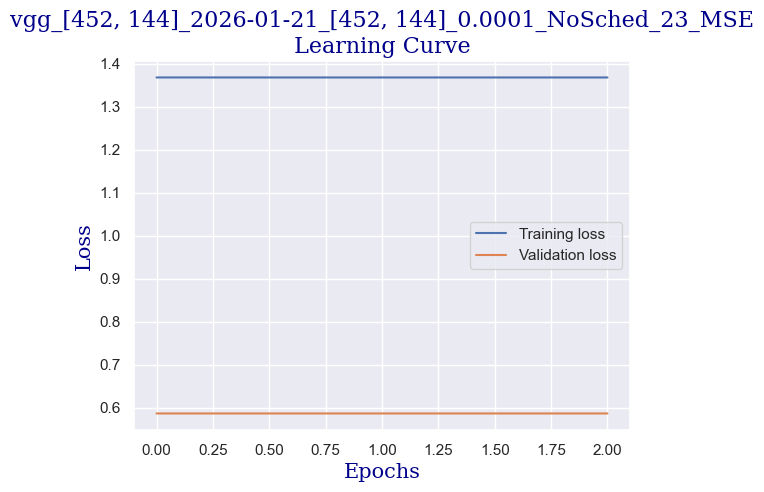

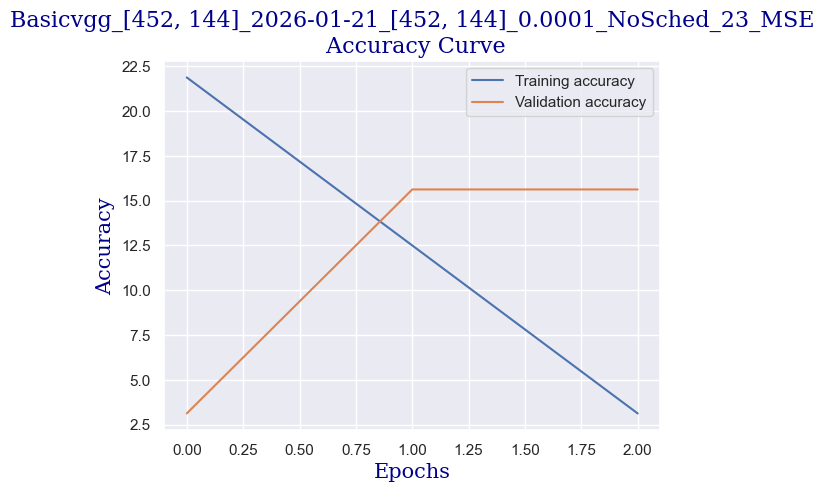

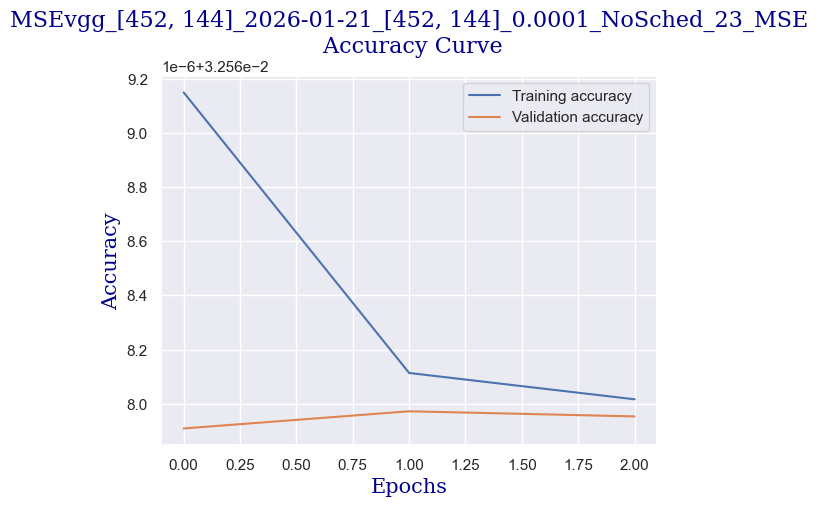

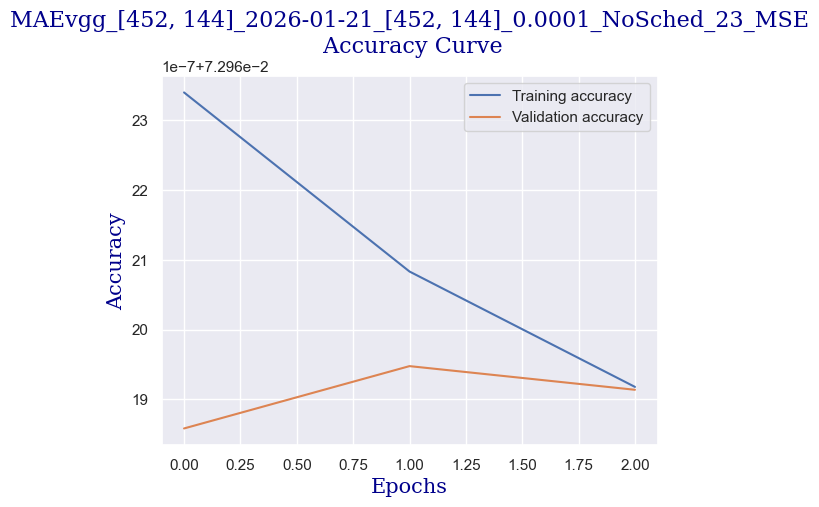

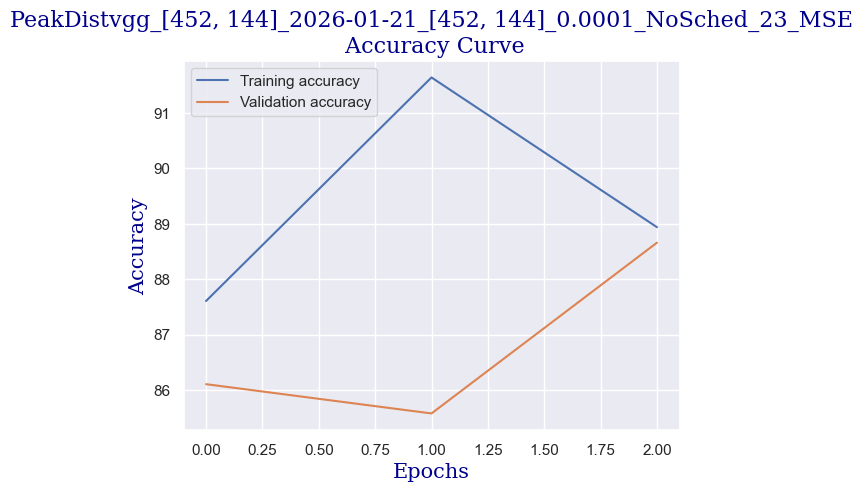

test_predict_numerical :   [318, 318, 343, 265, 342, 120, 343, 222, 94, 342, 222, 3, 290, 35, 343, 318, 267, 66, 290, 291, 343, 109, 181, 252, 47, 353, 222, 349, 166, 204, 349, 200, 342, 350, 26, 287, 222, 120, 326, 326, 120, 343, 349, 109, 176, 228, 343, 343, 211, 343, 197, 343, 66, 88, 349, 222, 26, 261, 156, 353, 109, 318, 318, 228, 349, 349, 290, 318, 318, 109, 109, 350, 222, 115, 222, 343, 349, 349, 343, 159, 35, 23, 120, 349, 222, 267, 342, 120, 318, 109, 67, 261, 318, 342, 349, 343, 222, 261, 343, 66, 67, 67, 343, 143, 333, 159, 318, 176, 35, 222, 349, 355, 349, 109, 343, 159, 251, 220, 67, 176, 131, 173, 349, 349, 176, 120, 176, 138, 353, 222, 26, 109, 159, 349, 261, 343, 252, 343, 290, 318, 222, 272, 35, 109, 318, 349, 71, 222, 349, 109, 318, 318, 222, 343, 261, 120, 343, 261, 330, 159, 109, 109, 159, 342, 205, 276, 343, 109, 175, 222, 318, 143, 342, 198, 343, 261, 198, 349, 222, 342, 35, 326, 343, 222, 222, 222, 265, 342, 120, 120, 222, 342, 50, 67, 318, 343, 164, 159, 220, 2

Traceback (most recent call last):
  File "/tmp/ipykernel_168506/3714808312.py", line 167, in _go
    plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
  File "/its/home/nn268/antvis/antvis/optics/Batchcode/p3/../.././plottingP3Direction.py", line 70, in plot_confusion
    disp.plot(cmap='plasma')
  File "/its/home/nn268/.local/lib/python3.10/site-packages/sklearn/metrics/_plot/confusion_matrix.py", line 181, in plot
    ax.set(
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 146, in <lambda>
    cls.set = lambda self, **kwargs: Artist.set(self, **kwargs)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1241, in set
    return self._internal_update(cbook.normalize_kwargs(kwargs, self))
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1233, in 

Epochs,▁
Test acc rough,▄▅▅▅▅▃▇▄▅▃▅█▂▆▃▆▅▃▄▁▆▂▃▄▅
TrainAcc rough,▂▃▃▂█▃▂▆▂▂▄▃▃▄▂▂▁▃▄▄▄▄▂▃▄▂▃▃▃▄▃▃▂▁▂▄▃▂▃▁
ValAcc rough,▇▅▆▄▅▁▅▅▅▆▄▃▅▁▄▆▄▂▁▅▄▅▂▄▅█▅▄▃▅▅▅▅▅▃▄▄▃▁▅
c_epoch,▁▅█
t_loss,█▂▁
test_acc_MAE,▅▇▁▇▂▃▃▃▄▅▃██▂▄▂▆▅▅▂▅▅█▃▃
test_acc_MSE,▄▆▁▇▃▃▂▃▃▄▃▇█▃▄▂▆▄▄▂▅▆█▃▃
test_peakDist,▃▃▅▆▃▆▃▃▄▆▃▁█▄▆▆▅▄▄▆▁▅▄▅▃
train_err_MAE,▄▁▂█▃▄▄▄▄▄▃▄▄▃▄▄▄▄▄▄▄▄▄▃▃▄▃▄▄▄▄▄▄▄▃▄▃▄▄▄
train_err_MSE,▄▄▁█▂▃▃▃▃▃▃▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃


Run pzmxwytt errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: ERROR Run pzmxwytt errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: c4hpwpa6 with config:
wandb: 	batch_size: 32
wandb: 	epochs: 3
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: MSE
wandb: 	model_cards: vgg
wandb: 	optimiser: adam
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 22
wandb: 	std_dev: 7


seed:  22
loss function:  MSE
Batch size:  32
Training epochs:  3
start time:  899.016752593
Model Name vgg
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  MSE


...

 67%|████████████████▋        | 2/3 [00:14<00:07,  7.21s/it]

peak dist means  91.32118055555556
v loss  0.5862228162586689
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  90.12276785714286
tacc:  {'baseAcc': 9.375, 'MSE': 0.03256788876439844, 'MAE': 0.07296109022129149, 'peakDist': 90.12276785714286}
Validating...


100%|█████████████████████████| 3/3 [00:21<00:00,  7.21s/it]

peak dist means  85.94097222222223
v loss  0.5862227007746696


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


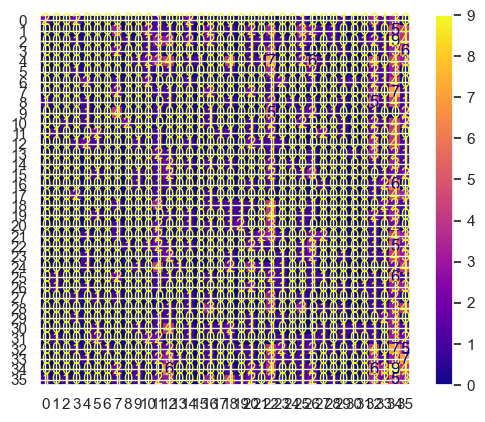

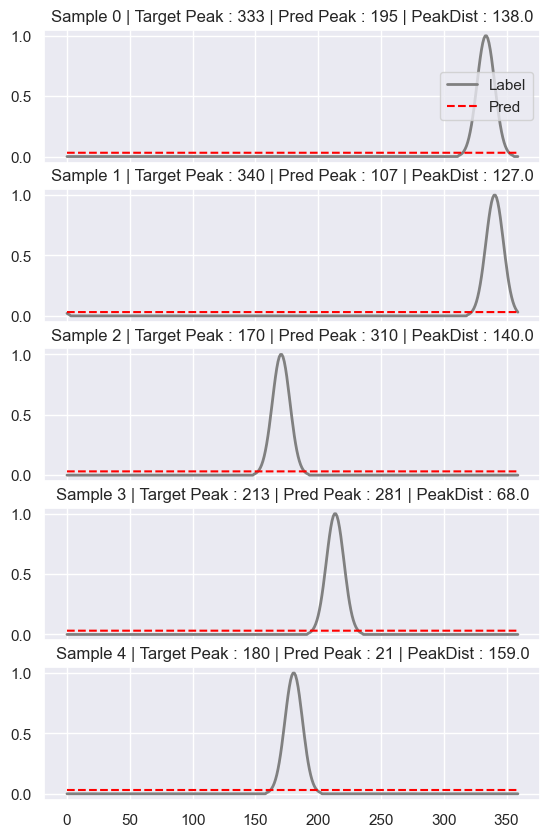

[  1   6   8   9  13  14  16  18  21  22  23  29  35  40  43  44  45  48
  53  54  59  64  66  70  71  73  76  79  80  83  84  87  92  93  94  98
 101 103 106 107 110 115 119 121 124 125 132 152 156 157 162 165 172 174
 175 185 189 190 191 194 195 200 209 212 231 242 243 244 249 252 253 256
 257 258 260 261 262 279 281 285 286 290 291 293 299 302 303 305 306 307
 310 312 314 315 322 330 333 334 338 341 344 347 348 350 352 354 358]
 
 train Acc:  {'baseAcc': 9.375, 'MSE': 0.03256788876439844, 'MAE': 0.07296109022129149, 'peakDist': 90.12276785714286}
 
 val Acc:  {'baseAcc': 18.75, 'MSE': 0.03256792678601212, 'MAE': 0.07296187223659621, 'peakDist': 85.94097222222223}
 
 test Acc:  {'BaseAcc': [9.375, 15.625, 12.5, 12.5, 15.625, 25.0, 12.5, 15.625, 12.5, 18.75, 18.75, 6.25, 18.75, 6.25, 9.375, 15.625, 9.375, 15.625, 15.625, 12.5, 12.5, 18.75, 12.5, 12.5, 9.375], 'MSE': [0.03256811201572418, 0.03256788104772568, 0.03256750851869583, 0.03256809711456299, 0.032567981630563736, 0.03256760537

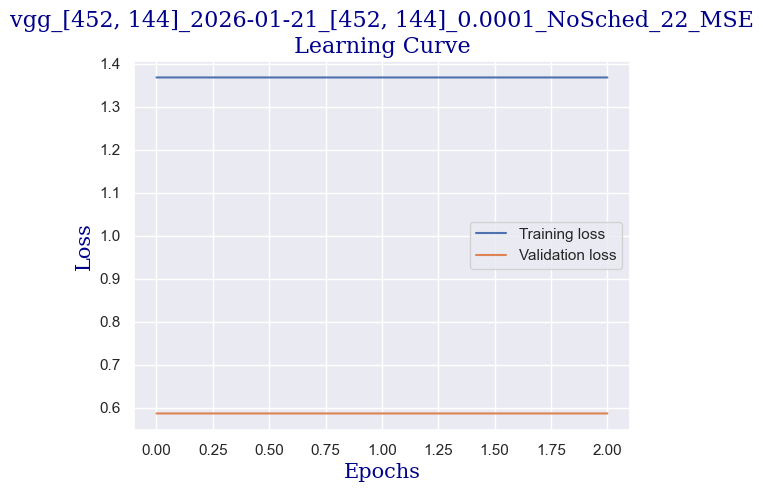

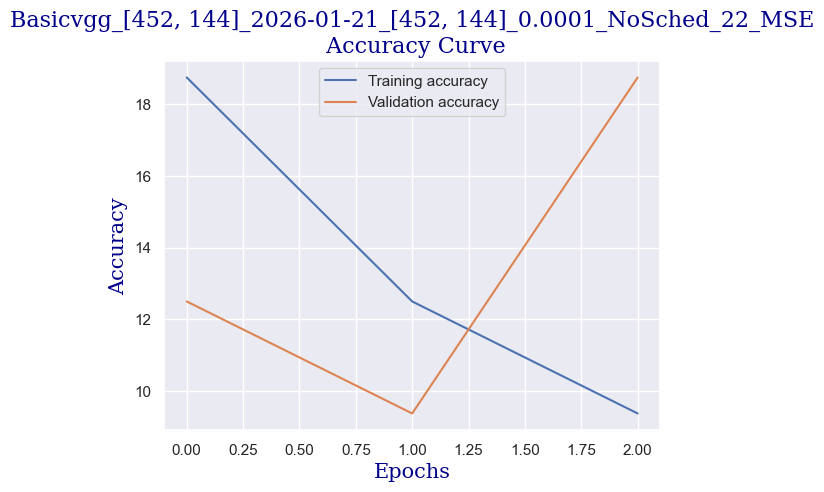

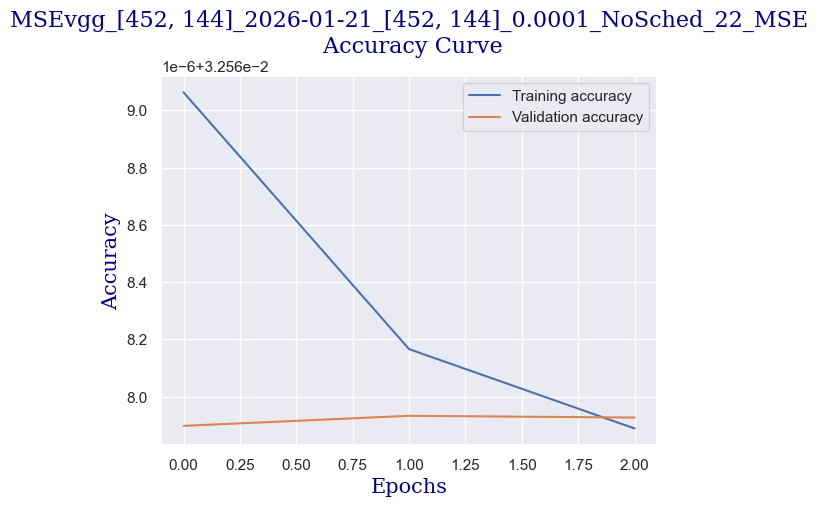

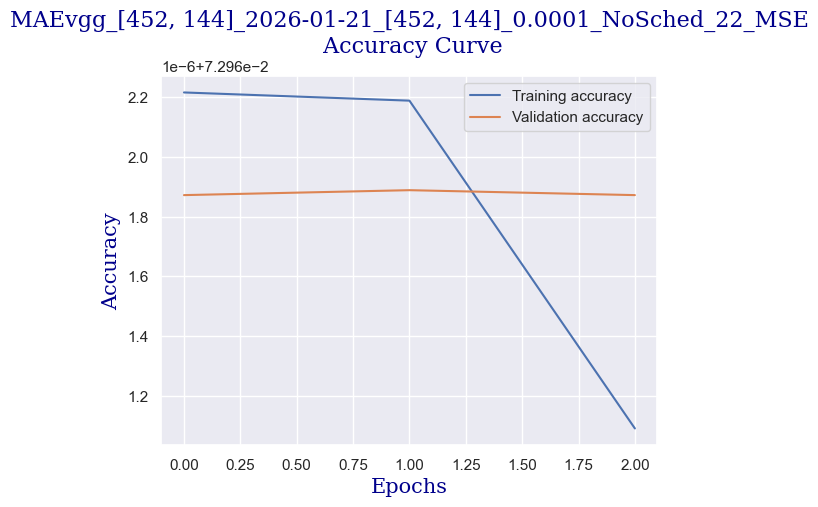

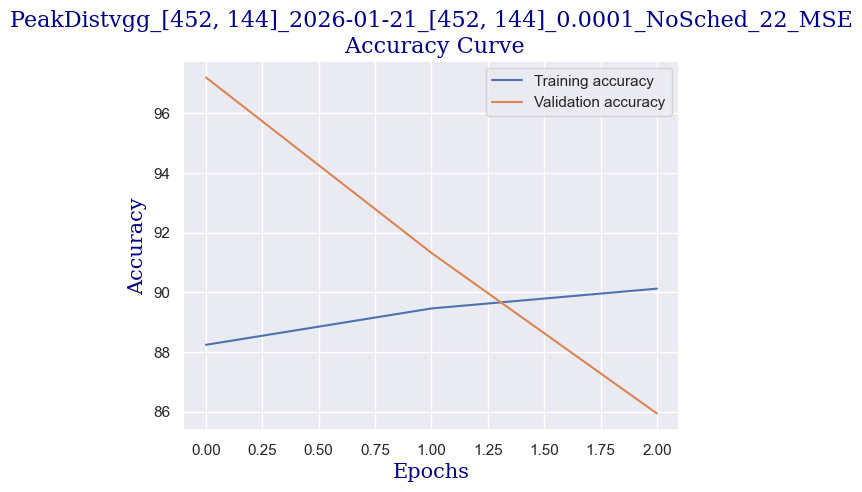

test_predict_numerical :   [302, 261, 107, 195, 281, 195, 119, 48, 195, 291, 107, 195, 286, 302, 119, 291, 195, 302, 195, 302, 302, 195, 291, 73, 195, 302, 119, 195, 302, 66, 21, 347, 302, 107, 195, 315, 195, 1, 291, 286, 302, 302, 352, 195, 195, 119, 191, 244, 302, 195, 195, 64, 107, 195, 302, 244, 195, 53, 119, 157, 286, 291, 209, 98, 302, 302, 291, 132, 302, 94, 83, 286, 302, 195, 195, 16, 291, 195, 94, 165, 152, 21, 174, 302, 302, 1, 195, 291, 195, 291, 93, 302, 162, 40, 45, 195, 302, 107, 302, 8, 195, 260, 286, 195, 162, 13, 354, 66, 73, 302, 98, 302, 195, 119, 125, 1, 347, 195, 358, 195, 54, 9, 8, 191, 101, 195, 286, 302, 302, 13, 286, 119, 286, 107, 16, 162, 106, 195, 302, 195, 119, 291, 195, 107, 87, 252, 119, 195, 195, 40, 195, 16, 98, 195, 195, 190, 13, 195, 302, 107, 281, 83, 73, 119, 195, 302, 16, 358, 195, 98, 195, 9, 13, 73, 322, 107, 1, 94, 107, 195, 1, 107, 302, 291, 302, 195, 14, 195, 302, 93, 291, 195, 291, 195, 195, 152, 21, 302, 21, 195, 1, 119, 162, 358, 286, 302, 

Traceback (most recent call last):
  File "/tmp/ipykernel_168506/3714808312.py", line 167, in _go
    plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
  File "/its/home/nn268/antvis/antvis/optics/Batchcode/p3/../.././plottingP3Direction.py", line 70, in plot_confusion
    disp.plot(cmap='plasma')
  File "/its/home/nn268/.local/lib/python3.10/site-packages/sklearn/metrics/_plot/confusion_matrix.py", line 181, in plot
    ax.set(
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 146, in <lambda>
    cls.set = lambda self, **kwargs: Artist.set(self, **kwargs)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1241, in set
    return self._internal_update(cbook.normalize_kwargs(kwargs, self))
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1233, in 

Epochs,▁
Test acc rough,▂▅▃▃▅█▃▅▃▆▆▁▆▁▂▅▂▅▅▃▃▆▃▃▂
TrainAcc rough,▂▂▃▄▄▂▃▄▄▃▆▅▄▆▄▅▅▇▄▅▃▄▃▃▅▆▄▇▃▅▆▅█▅▁▂▂▅▁▃
ValAcc rough,▃▃▁▃▁▂▁▄▁▂▅▃▃▃▃▂▂▅▂▂▁▃▂▇▃▂▂▄▂█▃▁▄▃▂▂▂▇▅▅
c_epoch,▁▅█
t_loss,█▃▁
test_acc_MAE,█▆▂█▆▁▅▄▂▂▇▆▄▃▂▆▂█▂▅▆▂▅▇▅
test_acc_MSE,█▅▁█▆▂▄▅▂▁▇▆▄▄▃▇▃█▁▆▆▃▅█▅
test_peakDist,▇▄▄▃▅▂▁▂▄▄▃▃▁▄▅▃█▅▆▅▃▂▄▅▄
train_err_MAE,▄▄█▆▃▂▄▂▃▅▃▂▄▄▄▃▄▅▄▄▄▃▄▃▃▂▄▂▁▃▄▆▄▂▄▁▄▄▄▅
train_err_MSE,▇▇▄█▃▅▇▃▄▄▄▁▃▄▅▃▄▅▄▄▃▃▃▃▂▂▃▃▃▅▄▅▄▂▄▂▄▄▃▅


Run c4hpwpa6 errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: ERROR Run c4hpwpa6 errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: Agent Starting Run: yzdc7vwt with config:
wandb: 	batch_size: 32
wandb: 	epochs: 3
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: MSE
wandb: 	model_cards: vgg
wandb: 	optimiser: adam
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 7
wandb: 	std_dev: 7


seed:  7
loss function:  MSE
Batch size:  32
Training epochs:  3
start time:  1121.005198893
Model Name vgg
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  MSE


...

 67%|████████████████▋        | 2/3 [00:14<00:07,  7.20s/it]

peak dist means  83.97743055555556
v loss  0.5862233825027943
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  89.20907738095238
tacc:  {'baseAcc': 9.375, 'MSE': 0.03256810970959209, 'MAE': 0.07296209179219745, 'peakDist': 89.20907738095238}
Validating...


100%|█████████████████████████| 3/3 [00:21<00:00,  7.21s/it]

peak dist means  88.27083333333333
v loss  0.5862233452498913


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


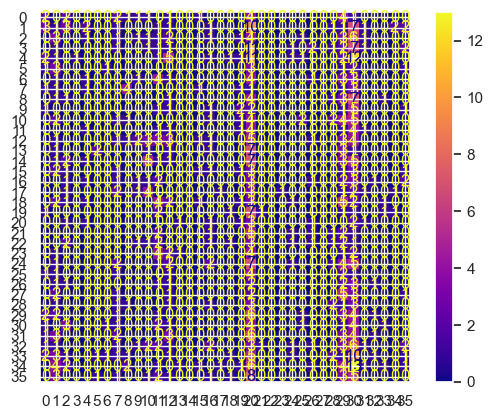

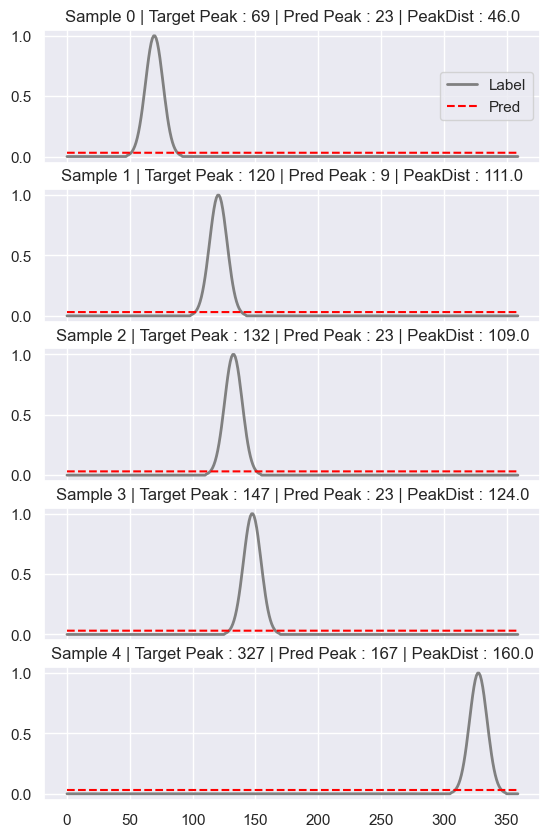

[  0   1   2   8   9  11  16  17  18  21  22  23  27  28  32  34  39  41
  43  51  52  56  57  58  60  64  66  69  70  74  76  78  79  82  83  84
  85  86  90  91  93  95  97 102 108 112 113 114 119 122 124 126 132 134
 139 140 144 148 150 151 157 158 165 167 170 180 182 186 189 192 200 201
 203 212 213 215 217 223 224 226 227 230 234 236 237 238 239 243 244 245
 247 250 251 260 262 263 264 266 267 272 280 283 284 285 286 288 293 300
 303 305 306 309 312 313 315 323 326 328 330 331 336 340 341 342 344 347
 348 350 352 353 354 356 359]
 
 train Acc:  {'baseAcc': 9.375, 'MSE': 0.03256810970959209, 'MAE': 0.07296209179219745, 'peakDist': 89.20907738095238}
 
 val Acc:  {'baseAcc': 18.75, 'MSE': 0.032567962590191096, 'MAE': 0.07296192480458154, 'peakDist': 88.27083333333333}
 
 test Acc:  {'BaseAcc': [3.125, 28.125, 25.0, 12.5, 21.875, 15.625, 9.375, 15.625, 15.625, 15.625, 18.75, 6.25, 25.0, 15.625, 18.75, 12.5, 25.0, 15.625, 21.875, 25.0, 28.125, 21.875, 9.375, 9.375, 9.375], 'MSE': [0.0

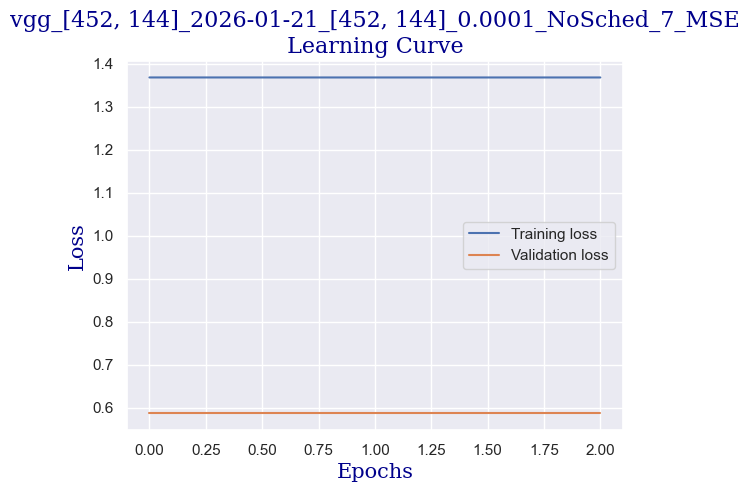

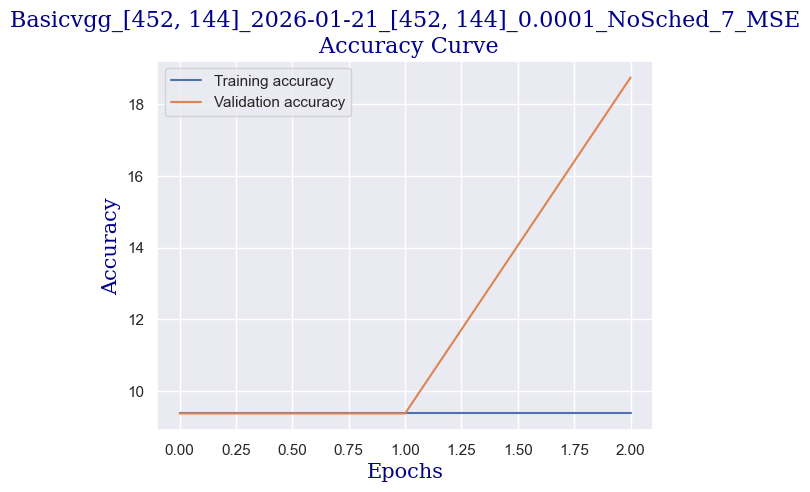

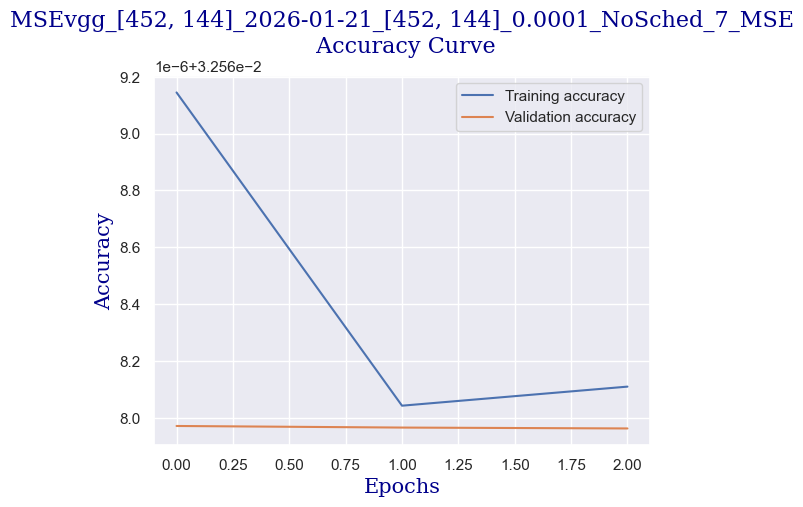

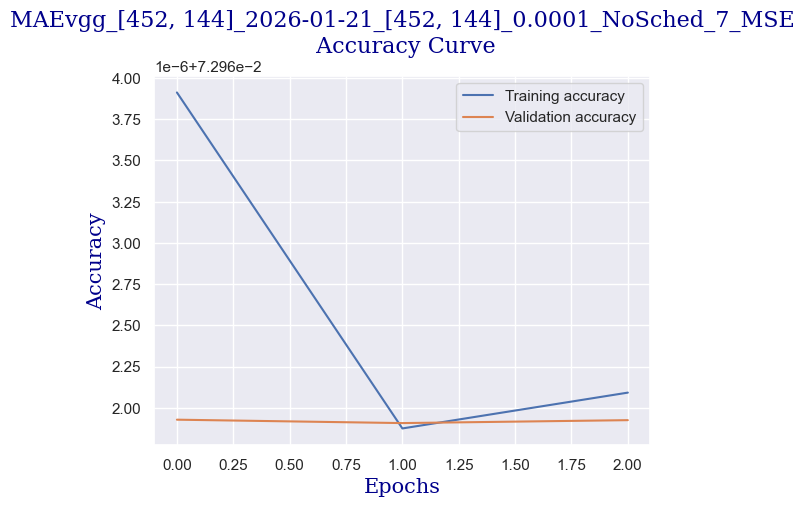

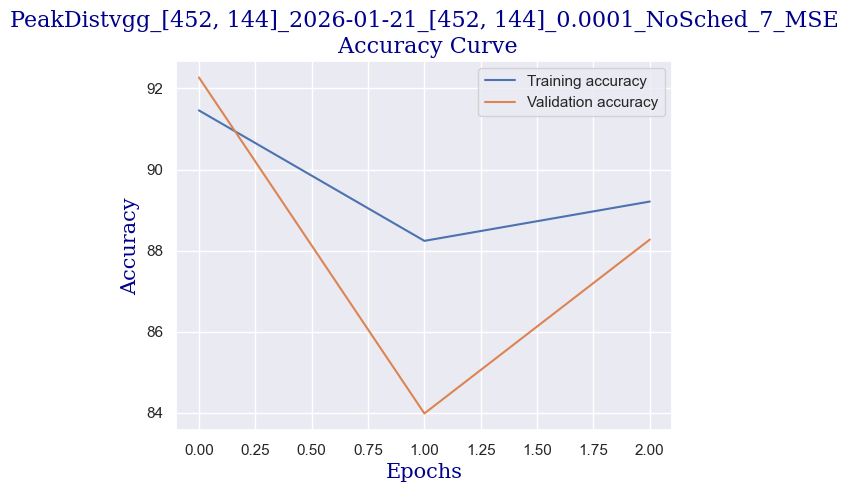

test_predict_numerical :   [303, 126, 58, 243, 114, 23, 167, 76, 251, 23, 85, 23, 91, 126, 328, 126, 43, 167, 39, 186, 23, 167, 32, 356, 39, 126, 90, 167, 236, 39, 286, 39, 212, 97, 305, 264, 23, 140, 66, 39, 27, 267, 215, 23, 23, 74, 167, 245, 0, 286, 74, 286, 359, 213, 303, 126, 39, 39, 39, 60, 126, 215, 23, 244, 167, 21, 74, 58, 303, 23, 126, 23, 167, 126, 126, 303, 157, 23, 293, 108, 23, 23, 247, 285, 23, 102, 303, 260, 286, 167, 303, 74, 167, 23, 284, 32, 234, 23, 167, 126, 303, 23, 27, 74, 286, 224, 23, 213, 39, 140, 39, 309, 352, 237, 286, 283, 126, 23, 39, 150, 32, 39, 66, 356, 74, 23, 126, 303, 23, 167, 167, 286, 39, 213, 23, 286, 34, 167, 108, 39, 303, 122, 300, 167, 170, 305, 52, 114, 23, 288, 315, 303, 28, 23, 23, 23, 32, 91, 83, 126, 84, 39, 23, 359, 126, 341, 203, 23, 167, 215, 126, 167, 23, 23, 167, 167, 286, 86, 227, 27, 306, 126, 167, 167, 39, 303, 250, 126, 126, 39, 23, 23, 303, 1, 151, 23, 148, 223, 286, 58, 23, 76, 167, 140, 126, 23, 303, 126, 226, 39, 39, 126, 78, 

Traceback (most recent call last):
  File "/tmp/ipykernel_168506/3714808312.py", line 167, in _go
    plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
  File "/its/home/nn268/antvis/antvis/optics/Batchcode/p3/../.././plottingP3Direction.py", line 70, in plot_confusion
    disp.plot(cmap='plasma')
  File "/its/home/nn268/.local/lib/python3.10/site-packages/sklearn/metrics/_plot/confusion_matrix.py", line 181, in plot
    ax.set(
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 146, in <lambda>
    cls.set = lambda self, **kwargs: Artist.set(self, **kwargs)
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1241, in set
    return self._internal_update(cbook.normalize_kwargs(kwargs, self))
  File "/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/artist.py", line 1233, in 

Epochs,▁
Test acc rough,▁█▇▄▆▅▃▅▅▅▅▂▇▅▅▄▇▅▆▇█▆▃▃▃
TrainAcc rough,▅▅▅▅▄▃▃▅▅▂█▇▃▃▆▃▄▁▅▄▅▇▂▄▆▅▃▂▃▂▂▄▃▁▁▅▃▃▃▃
ValAcc rough,▆▄▅▄▃▃▁▁▃▄▆▃▂▃█▃▃▃▅▁▁▅▅▄█▅▃▄▄▁▅▅▆▃▂▅▄▅▄▅
c_epoch,▁▅█
t_loss,█▁▁
test_acc_MAE,█▃▃▅▅▄▁▃▂▆▅▂▆▅▁▃▃▅▃▂▅▃▅▆▁
test_acc_MSE,█▅▄▄▅▄▄▄▅▆▇▃▆▅▃▄▃▇▃▁▆▄▅▆▄
test_peakDist,█▃▄▅▄▅▅▄▂▄▄▅▄▆▄▆▃▄▃▄▁▅▅▄▅
train_err_MAE,▁▇█▂▁▅▃▂▂▂▂▃▂▂▂▁▁▁▂▂▁▂▂▂▁▁▂▁▁▂▂▂▂▂▂▂▂▂▂▂
train_err_MSE,▂▆█▂▁▅▃▂▃▂▃▃▂▂▁▂▂▂▃▂▂▃▂▃▂▂▂▂▂▃▂▂▂▂▂▂▂▂▂▂


Run yzdc7vwt errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
wandb: ERROR Run yzdc7vwt errored: ValueError('The number of FixedLocator locations (36), usually from a call to set_ticks, does not match the number of labels (4).')
Detected 5 failed runs in a row at start, killing sweep.
wandb: ERROR Detected 5 failed runs in a row at start, killing sweep.
wandb: To change this value set WANDB_AGENT_MAX_INITIAL_FAILURES=val


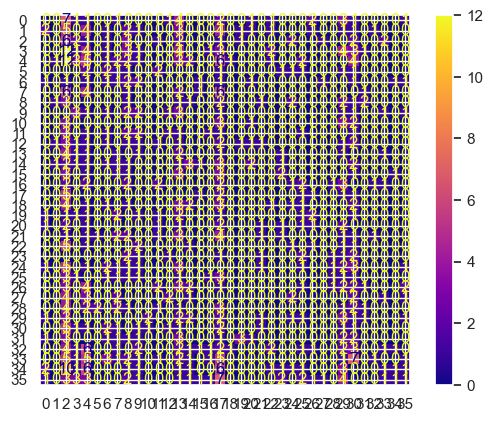

In [9]:
if len(gitHASH) <1:
    print("YOU FORGET THE GIT HASH")
else:
    print('Git Hash registered')


sweep_id = wandb.sweep(sweep = config, project=projectNAME)

wandb.agent(sweep_id, function = _go, count=36)